# 3. Update the MMM with experimental evidence

**Hypothetical experimental evidence.** Assume an independent experiment reports incremental return 1.20, with standard error 0.15, for Channel2 +20% over eight weeks, counting twelve followup weeks. The target covers all 40 geos.

The estimate and its precision are specified as inputs to this calibration scenario; they are not measured field results. The earlier experiment-design exploration is summarized in `../docs/exploration_notes.md` and is not required to reproduce this module.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown, Image
ROOT=Path.cwd()
if not (ROOT/'reports').is_dir(): ROOT=ROOT.parent
assert (ROOT/'reports/data_audit.json').is_file(), 'Run from the repository root or notebooks directory.'
s=json.loads((ROOT/'reports/illustrative_calibration/comparison_summary.json').read_text())
e=s['experiment']
print('Hypothetical experimental return:',e['observed_incremental_return'],'; SE:',e['standard_error_incremental_return'])
print('Equivalent incremental revenue:',round(e['observed_incremental_revenue'],2),'CU')

Hypothetical experimental return: 1.2 ; SE: 0.15
Equivalent incremental revenue: 60450.19 CU


## Add one independent likelihood

For each candidate parameter vector $\theta$, replay the two exposure schedules to calculate the experimental contrast $g(\theta)$. Then:

$$p(\theta\mid D_{history},D_{experiment})\propto p(\theta\mid D_{history})\,p(\widehat\Delta_{experiment}\mid g(\theta)).$$

The likelihood is Normal with the stipulated experiment SE. Historical priors and likelihood remain unchanged. The summary enters once; no underlying experimental outcomes are also added. Scaling the likelihood into return units changes only a parameter-independent density constant.

Four fresh MCMC chains produce the calibrated parameter posterior. One effect estimate can constrain parameter combinations without separately identifying decay, saturation and regional coefficients.

Before: 2.14 [1.34, 3.53] (90% posterior interval)
After: 1.31 [1.10, 1.53] (90% posterior interval)


chains                                                                      4
warmup_per_chain                                                         1000
draws_per_chain                                                          1000
elapsed_seconds                                                    404.332974
divergences                                                                 0
max_rhat                                                             1.007834
min_bulk_ess                                                       1063.91918
min_tail_ess                                                      1501.411701
max_mcse_over_sd                                                      0.03052
tree_depth_limit_count                                                      0
bfmi_per_chain              [0.8548192888449296, 0.8124025931711435, 0.783...
priors_changed                                                          False
calibration                       Hypothetical Normal experiment

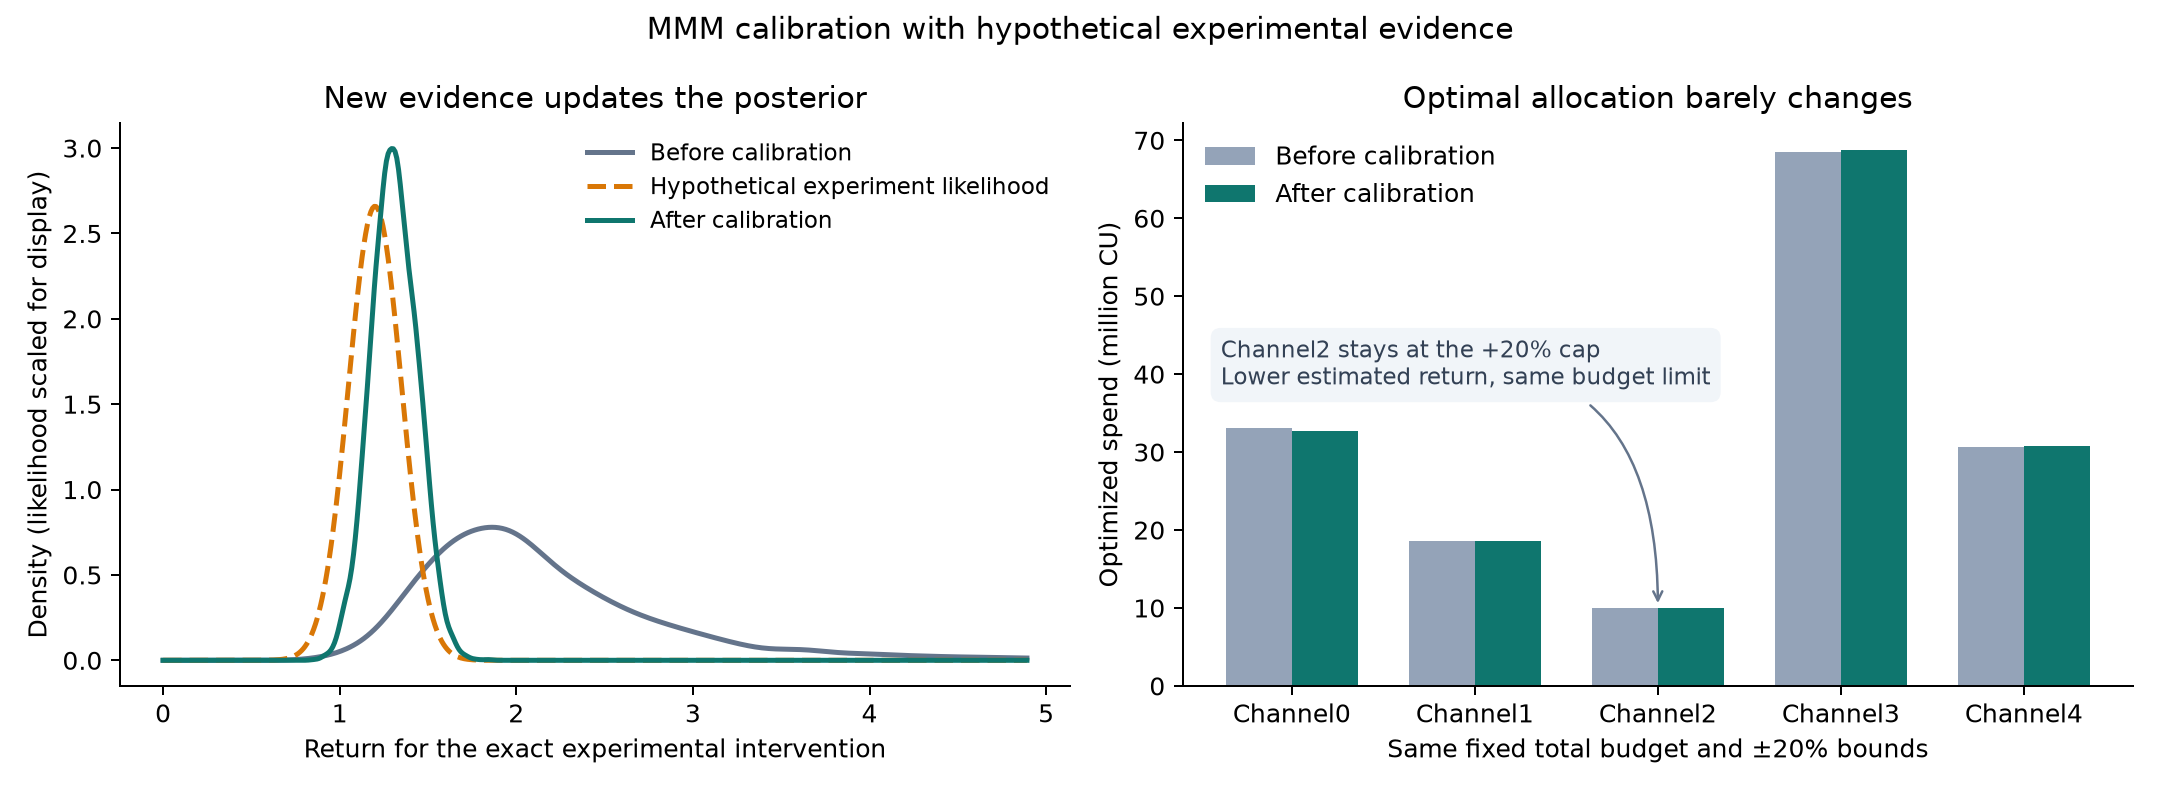

In [2]:
for label,key in [('Before','experiment_return_before'),('After','experiment_return_after')]:
    r=s[key]
    print(f"{label}: {r['mean']:.2f} [{r['lo90']:.2f}, {r['hi90']:.2f}] (90% posterior interval)")
display(pd.Series(s['diagnostics']))
display(Image(filename=str(ROOT/'reports/illustrative_calibration/calibration_workflow.png')))

## Recompute effects and decisions

Historical channel ROAS and the experimental intervention return have different time windows and counterfactuals; they should not be equated. The updated historical marginal ROAS for Channel2 falls from 2.02 to 1.35. Re-optimize the same fixed budget with the same ±20% bounds.

In [3]:
display(Markdown((ROOT/'reports/illustrative_calibration/channel_comparison.md').read_text()))
display(Markdown((ROOT/'reports/illustrative_calibration/allocation_comparison.md').read_text()))
r=s['new_optimization_under_calibrated_posterior']
print(f"Updated policy versus original spend: {r['mean']/1e6:.2f} million CU [{r['lo90']/1e6:.2f}, {r['hi90']/1e6:.2f}]")
r=s['new_vs_old_policy_under_same_calibrated_posterior']
print(f"New versus old optimized policy, both under updated posterior: {r['mean']:,.0f} CU [{r['lo90']:,.0f}, {r['hi90']:,.0f}]")

Updated policy versus original spend: 1.43 million CU [-2.52, 5.13]
New versus old optimized policy, both under updated posterior: 1,911 CU [-253,606, 202,502]


| Channel | ROAS before | ROAS after | Marginal ROAS before | Marginal ROAS after |
|---|---:|---:|---:|---:|
| Channel0 | 2.39 [0.83, 4.64] | 2.36 [0.90, 4.53] | 1.13 [0.47, 2.01] | 1.14 [0.49, 1.97] |
| Channel1 | 1.43 [0.61, 2.78] | 1.49 [0.63, 2.84] | 0.79 [0.39, 1.37] | 0.82 [0.40, 1.41] |
| Channel2 | 3.14 [2.16, 4.61] | 2.25 [1.79, 2.73] | 2.02 [1.32, 3.07] | 1.35 [1.06, 1.68] |
| Channel3 | 1.52 [1.17, 1.90] | 1.54 [1.19, 1.93] | 1.06 [0.80, 1.32] | 1.07 [0.83, 1.34] |
| Channel4 | 1.42 [1.06, 1.81] | 1.44 [1.06, 1.85] | 0.95 [0.69, 1.23] | 0.96 [0.70, 1.25] |


| Channel | Original spend (million CU) | Optimized before calibration | Optimized after calibration | Change from original after calibration |
|---|---:|---:|---:|---:|
| Channel0 | 29.74 | 33.09 | 32.77 | +10.2% |
| Channel1 | 23.29 | 18.63 | 18.63 | -20.0% |
| Channel2 | 8.31 | 9.97 | 9.97 | +20.0% |
| Channel3 | 64.76 | 68.53 | 68.78 | +6.2% |
| Channel4 | 34.77 | 30.66 | 30.72 | -11.6% |


## Takeaway

The new evidence lowers the inferred return and reduces its posterior SD by about 81%, but Channel2 remains at the +20% allocation bound. An informative experiment need not reverse a decision. Optimization gains remain uncertain.

Comparing old and new allocations under the **same** posterior isolates the decision change from changed beliefs. For the stakeholder-facing recommendation, limitations and implementation conditions, read `../docs/decision_memo.md`.

## Extension: decision-focused experiment prioritization

The preceding analysis updates beliefs for one stipulated result. This extension asks **before observing a result** which experiment could improve allocation. It therefore starts again from the original historical-data posterior, without the hypothetical calibration evidence.

Compare five single-channel +20% interventions (8 weeks plus 12 followup weeks) at assumed return SEs 0.60, 0.30 and 0.15. Expected value of sample information averages the revenue advantage of choosing an allocation after observing evidence over keeping the current optimal allocation. Whole posterior draws are likelihood-reweighted; predictive quadrature integrates over possible summary results.

The budget decision replays the existing 118-week historical scenario. Values exclude experiment costs, margins and delay costs. See [the full protocol](../docs/experiment_prioritization.md).

se_return,0.15,0.30,0.60
channel,,,
Channel0,1308428.0,1088305.0,668284.0
Channel1,456750.0,342416.0,154183.0
Channel2,31580.0,23624.0,15532.0
Channel3,349313.0,156003.0,48757.0
Channel4,293438.0,138606.0,45427.0


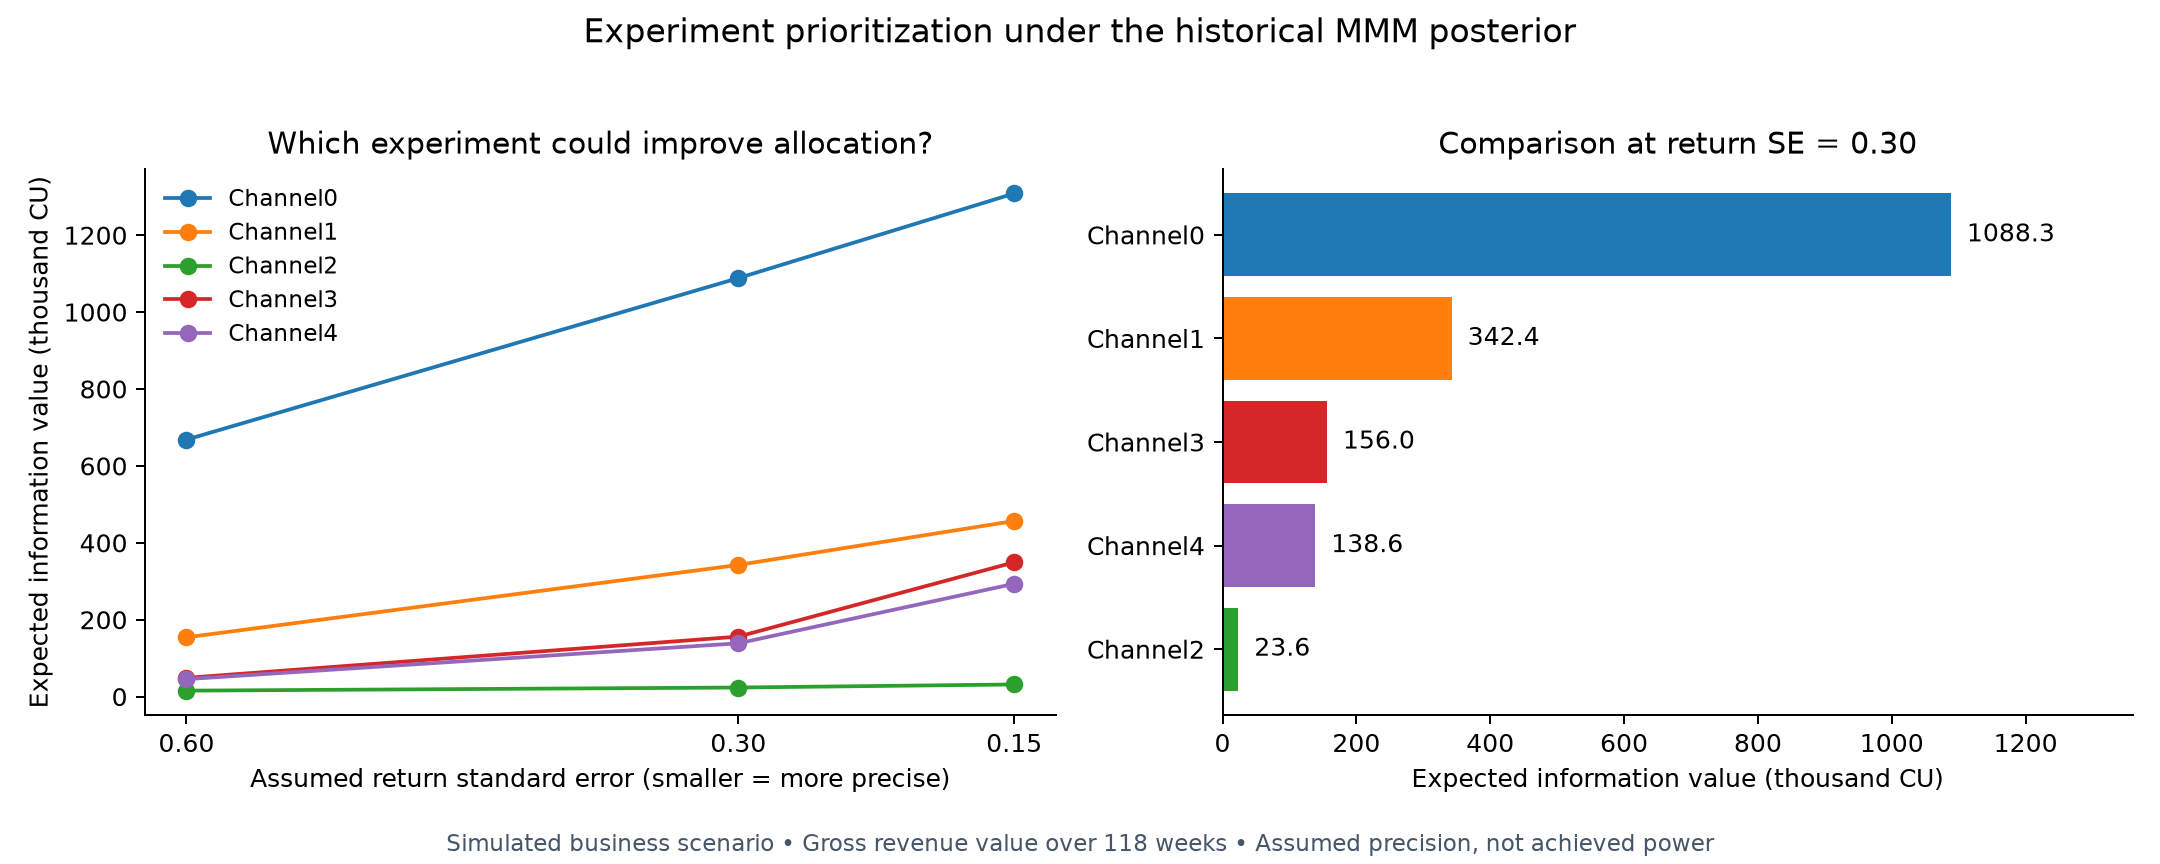

In [4]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Image
screen = pd.read_csv(Path('../reports/experiment_prioritization/candidate_results.csv'))
display(screen.pivot(index='channel', columns='se_return', values='evsi_cu').round(0))
display(Image(filename='../reports/experiment_prioritization/experiment_value.png'))

**Interpretation.** Channel0 ranks highest and Channel2 lowest across the three precision assumptions and both chain-group checks. At SE 0.30, Channel2 remains at its upper allocation bound for approximately 99.98% of possible experimental summaries under this model. Uncertainty reduction and decision improvement are different objectives.

**Limits.** Numerical integration differences are below 8 CU, but finite posterior uncertainty is larger. For Channel2 at SE 0.30, the two chain groups yield EVSI of about 19.6k and 33.0k CU, versus 23.6k for all draws. At SE 0.15, 3.56% of Channel2 predictive probability has weight ESS below 100. These are sensitivity diagnostics, not confidence intervals. A real experiment recommendation still needs feasible precision, costs and an appropriate future decision horizon.

## Channel0: expand the intervention intensity

Compare −20%, +10%, and +20% spending changes for eight weeks plus twelve followup weeks. Within each tier, hold **revenue-summary SE** constant, rather than return SE. This makes +10% twice as noisy in return units as +20%. Negative revenue and spending changes for the cut mean a loss and a saving, respectively.

The same historical-data posterior and 118-week downstream decision apply. Test economics are reported separately from information value. See [design definitions](../docs/channel0_designs.md).

,intensity_pct,spend_change_cu,revenue_change_mean_cu,se_revenue_cu,evsi_cu,expected_budget_moved_pct
1,-20.0,-396345.96,-516863.43,118903.79,1135955.68,2.87
4,10.0,198172.98,235315.58,118903.79,684830.26,2.47
7,20.0,396345.96,457369.36,118903.79,1088304.88,2.84


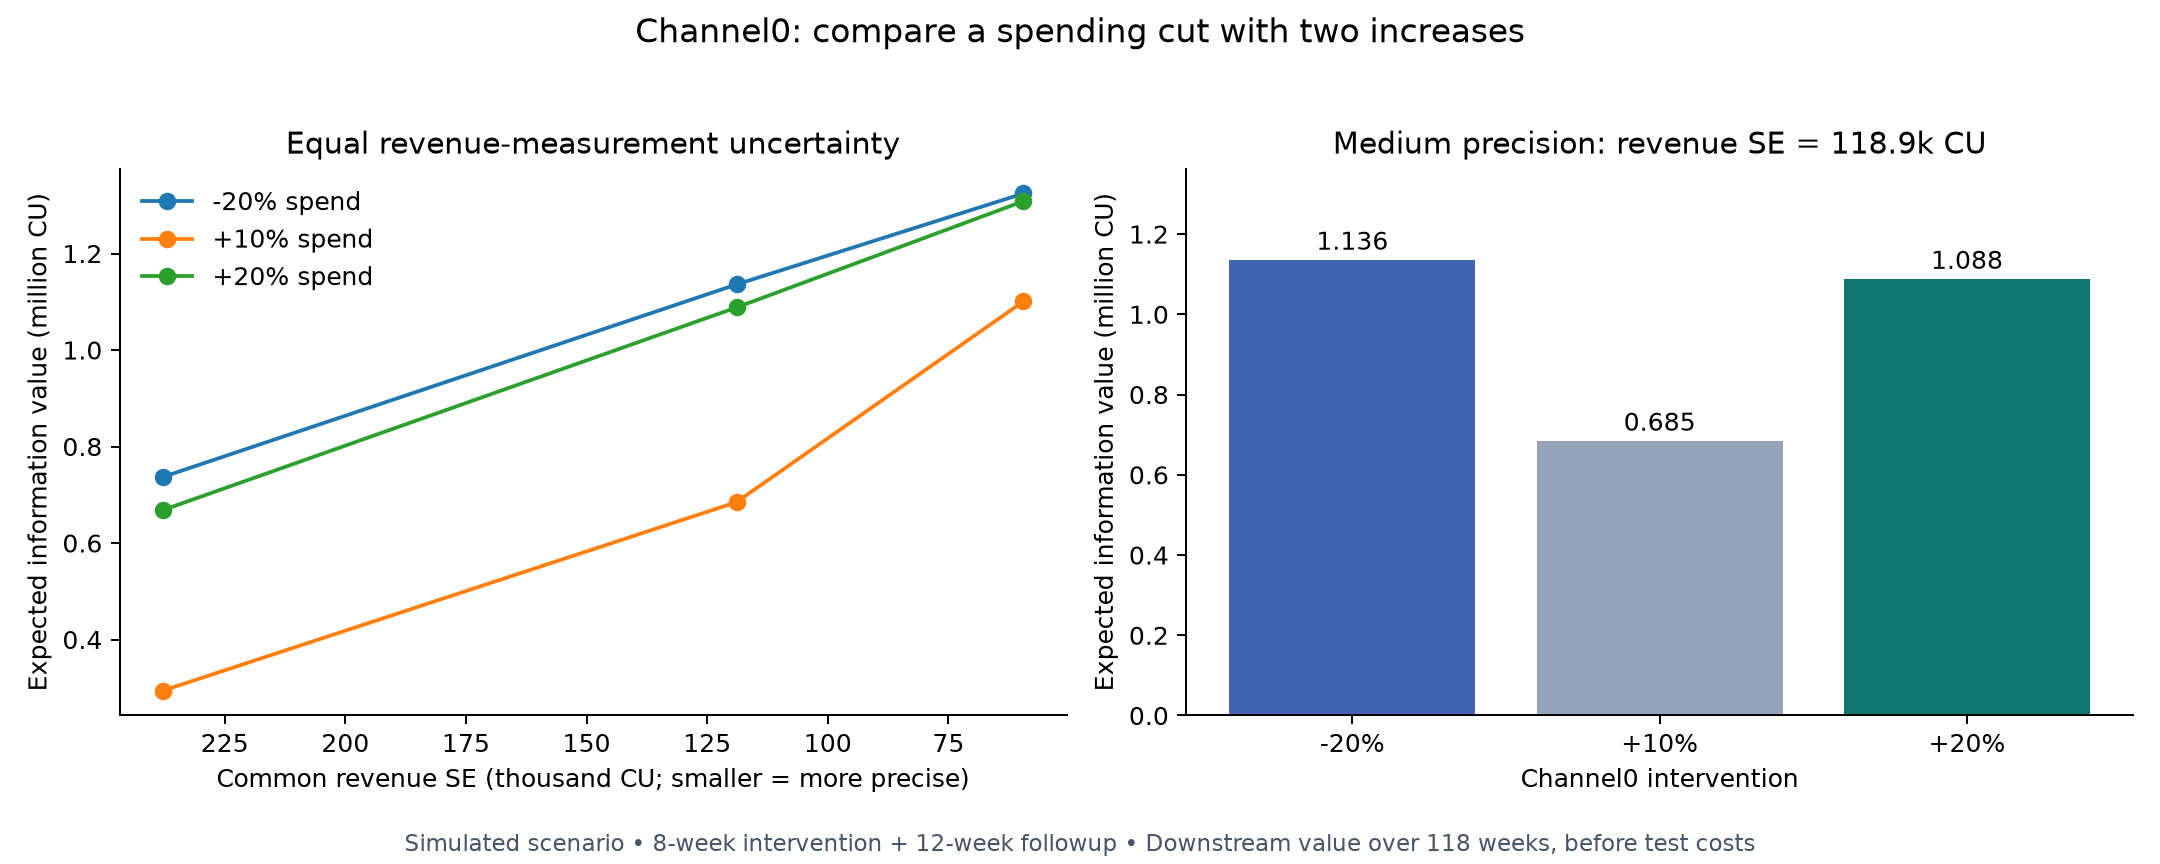

In [5]:
designs = pd.read_csv('../reports/channel0_designs/design_comparison.csv')
display(designs.loc[designs.precision == 'medium', ['intensity_pct', 'spend_change_cu', 'revenue_change_mean_cu', 'se_revenue_cu', 'evsi_cu', 'expected_budget_moved_pct']].round(2))
display(Image(filename='../reports/channel0_designs/intensity_comparison.png'))

The cut has the highest gross information value in these scenarios, but its medium-precision lead over +20% is only about 47.7k CU. The concave response makes the negative contrast larger in magnitude under the same revenue noise. The expected test-period revenue loss is about 516.9k CU, with 396.3k CU of saved media spend; these are different quantities from downstream EVSI. Margins, test costs, feasible precision and opportunity costs are still needed for a business recommendation.

The +20% scenario reproduces the first-stage results; quadrature changes are below 10 CU. Both chain groups preserve the ranking, but these checks do not establish robustness to modeling assumptions. Keep the cut and +20% increase on the shortlist rather than choosing solely on EVSI.